# 01 · Ingesta y exploración (EDA)

**Fuente:** `data/HISTORICO_MF_HACKATON2026 (1).xlsx`, hoja `Datos`.

Este notebook: carga el histórico real del programa de Medicina Funcional, corrige los tipos de dato (decimales con coma, columnas mixtas texto/número), descarta registros fisiológicamente imposibles y explora la distribución de las variables clínicas y de estilo de vida — el insumo para decidir, en el notebook 03, qué variables y cuántos clusters describen mejor a la población.

**Salida:** `data/_processed/01_raw_clean.csv`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

RAW_PATH = '../data/HISTORICO_MF_HACKATON2026 (1).xlsx'
df = pd.read_excel(RAW_PATH, sheet_name='Datos')
df.columns = [c.strip() for c in df.columns]
print('shape:', df.shape)
print('pacientes únicos:', df.iloc[:, 0].nunique())
df.head()

shape: (16204, 20)
pacientes únicos: 4388


,Número de documento del usuario,¿Está realizando alguno de los siguientes hábitos saludables en la alimentación?,¿Realiza alguna de las siguientes actividades físicas? ¿En qué duración?,¿Cuál es la duración en tiempo de la actividad física que realiza?,¿Cuál es la frecuencia en la semana que realiza actividad física?,¿Considera tener altas cargas de estrés?,¿Se considera una persona ansiosa?,¿Se considera una persona nerviosa?,¿Utiliza alguna técnica de gestión de estrés (meditación oración ejercicio respiración)?,¿Uso de alguno de estos medicamentos?,Perímetro abdominal,Peso,Talla,IMC,Cifras de Presión Arterial Sistólica Diastólica Ejemplo: 110,Cifras de Presión Arterial Sistólica Diastólica Ejemplo: 1105,¿Ha presentado algunos siguientes signos o síntomas gastrointestinales?,COLESTEROL TOTAL,COLESTEROL HDL,HEMOGLOBINA GLICOSILADA (HBA1C)
0,43041805,Ninguno;,"Cardiovascular (caminar, trotar, spinning, bic...",Más de 30 minutos,Ninguno;,No,Sí,Sí,No,Ninguno,113,86,1.65,31.588613,118,78,Ninguno;,152,47,5.9
1,42983595,Incorporar más vegetales en su alimentación;Au...,Ninguno;,Ninguno;,Ninguno;,No,No,No,No,Hipolipemiantes;,100,74,1.59,29.270994,118,78,Ninguno;,199,55,5.6
2,49655828,Ninguno;,"Cardiovascular (caminar, trotar, spinning, bic...",Más de 30 minutos,Ninguno;,No,Sí,No,No,Ninguno,99,78,1.51,34.209026,118,78,Ninguno;,200,52,5.9
3,1000412929,Ninguno;,"Cardiovascular (caminar, trotar, spinning, bic...",Más de 30 minutos,Ninguno;,No,Sí,Sí,No,Ninguno,62,45,1.52,19.477147,118,78,Ninguno;,180,61,5.2
4,1026164585,Incorporar más vegetales en su alimentación;Au...,"Cardiovascular (caminar, trotar, spinning, bic...",Más de 30 minutos,Ninguno;,No,Sí,No,No,Ninguno,63,25,1.05,22.675737,118,78,Ninguno;,160,48,5.2


## Renombrar columnas a nombres cortos

El Excel trae las preguntas completas como encabezado; se renombran a claves cortas para trabajar más cómodo (el orden de las columnas es fijo en el archivo fuente).

In [2]:
COLS = [
    'doc', 'habitos', 'tipo_actividad', 'duracion_actividad', 'frecuencia_actividad',
    'estres_alto', 'ansioso', 'nervioso', 'tecnica_estres', 'medicamentos',
    'perimetro', 'peso', 'talla', 'imc', 'pa_sistolica', 'pa_diastolica',
    'sintomas_gi', 'colesterol_total', 'colesterol_hdl', 'hba1c',
]
df.columns = COLS
df.dtypes

doc                       int64
habitos                  object
tipo_actividad           object
duracion_actividad       object
frecuencia_actividad     object
estres_alto              object
ansioso                  object
nervioso                 object
tecnica_estres           object
medicamentos             object
perimetro                object
peso                     object
talla                    object
imc                     float64
pa_sistolica              int64
pa_diastolica            object
sintomas_gi              object
colesterol_total          int64
colesterol_hdl            int64
hba1c                   float64
dtype: object

## Limpieza de tipos

`perimetro`, `peso`, `talla` y `pa_diastolica` llegan como texto en algunas filas porque usan coma decimal (formato es-CO, ej. `78,5`). `imc`, `pa_sistolica`, `colesterol_total`, `colesterol_hdl` y `hba1c` ya llegan numéricos.

In [3]:
def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(',', '.').str.strip(), errors='coerce')

for c in ['perimetro', 'peso', 'talla', 'pa_diastolica']:
    df[c] = to_num(df[c])
df[['perimetro', 'peso', 'talla', 'imc', 'pa_sistolica', 'pa_diastolica']].describe().round(2)

,perimetro,peso,talla,imc,pa_sistolica,pa_diastolica
count,16204.00,16204.00,16204.00,16204.00,16204.00,16199.00
mean,90.83,72.65,1.60,28.39,118.30,76.98
std,15.47,16.21,0.09,5.71,8.25,5.84
min,0.00,5.20,1.05,2.37,0.00,0.00
25%,81.00,61.00,1.54,24.34,118.00,76.00
50%,90.00,71.00,1.59,27.49,118.00,78.00
75%,99.00,82.00,1.65,31.86,120.00,80.00
max,961.00,156.00,1.95,65.57,240.00,120.00


## Valores fisiológicamente imposibles

Errores de captura manual (ej. tallas en cm en vez de m, presiones a 0) producen valores fuera de cualquier rango humano plausible. Se descartan con un filtro conservador (rangos amplios, no clínicos estrictos) para no perder casos válidos pero atípicos.

In [4]:
mask_valid = (
    df['imc'].between(10, 70)
    & df['talla'].between(1.0, 2.2)
    & df['peso'].between(25, 250)
    & df['perimetro'].between(40, 200)
    & df['pa_sistolica'].between(60, 250)
    & df['pa_diastolica'].between(30, 150)
    & df['colesterol_total'].between(50, 500)
    & df['colesterol_hdl'].between(10, 150)
    & df['hba1c'].between(3.5, 20)
)
print('descartados:', (~mask_valid).sum(), 'de', len(df))
df = df[mask_valid].reset_index(drop=True)
print('shape final:', df.shape, '| pacientes únicos:', df['doc'].nunique())

descartados: 29 de 16204
shape final: (16175, 20) | pacientes únicos: 4382


## Distribución de variables clínicas

In [5]:
clinical_cols = ['imc', 'perimetro', 'pa_sistolica', 'pa_diastolica', 'colesterol_total', 'colesterol_hdl', 'hba1c']
df[clinical_cols].describe().round(2)

,imc,perimetro,pa_sistolica,pa_diastolica,colesterol_total,colesterol_hdl,hba1c
count,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00,16175.00
mean,28.39,90.82,118.35,77.01,193.05,49.25,5.59
std,5.70,13.77,7.93,5.63,40.51,11.76,0.59
min,14.44,41.00,84.00,50.00,67.00,19.00,4.00
25%,24.34,81.00,118.00,76.00,167.00,41.00,5.30
50%,27.48,90.00,118.00,78.00,192.00,48.00,5.50
75%,31.85,99.00,120.00,80.00,215.00,55.00,5.70
max,65.57,195.00,240.00,120.00,423.00,133.00,14.40


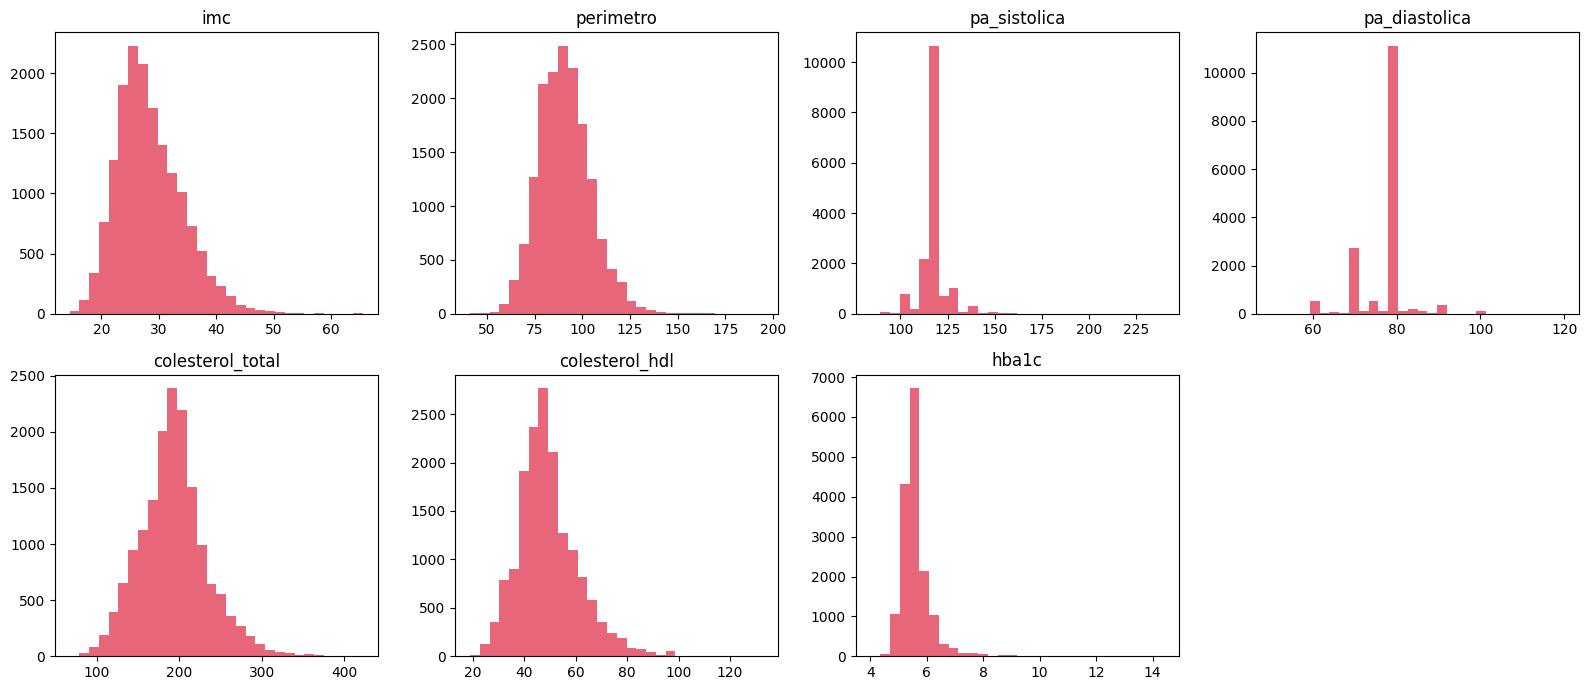

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, clinical_cols):
    ax.hist(df[col].dropna(), bins=30, color='#E0334C', alpha=0.75)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

## Variables categóricas y de estilo de vida

Estrés, ansiedad, nerviosismo y técnica de manejo del estrés son binarias (Sí/No). Hábitos alimentarios, tipo de actividad física y síntomas gastrointestinales son de selección múltiple (separadas por `;`).

In [7]:
for c in ['estres_alto', 'ansioso', 'nervioso', 'tecnica_estres']:
    print(f'--- {c} ---')
    print(df[c].value_counts(dropna=False))
    print()

--- estres_alto ---
estres_alto
No    13489
Sí     2686
Name: count, dtype: int64

--- ansioso ---
ansioso
No    8141
Sí    8034
Name: count, dtype: int64

--- nervioso ---
nervioso
No    8347
Sí    7828
Name: count, dtype: int64

--- tecnica_estres ---
tecnica_estres
No    13767
Sí     2407
SÍ        1
Name: count, dtype: int64



In [8]:
print('--- medicamentos (top 10) ---')
print(df['medicamentos'].value_counts().head(10))
print()
print('--- síntomas gastrointestinales (top 10) ---')
print(df['sintomas_gi'].value_counts().head(10))

--- medicamentos (top 10) ---
medicamentos
Ninguno                                                                                                9859
Hipolipemiantes;                                                                                       2343
Hipoglicemiantes; Hipolipemiantes                                                                      1785
Inhibidores de la bomba de protones (Esomeprazol, lanzoprazol, pantoprazol, omeprazol);                 896
Hipoglicemiantes;                                                                                       521
Antiácidos ;Inhibidores de la bomba de protones (Esomeprazol, lanzoprazol, pantoprazol, omeprazol);     385
Antiácidos;                                                                                             251
Antiácidos;Inhibidores de la bomba de protones (Esomeprazol, lanzoprazol, pantoprazol, omeprazol);      110
Hipolipemiantes                                                                              

## Conclusión del EDA inicial

- La mayoría de la población (~78%) no reporta síntomas gastrointestinales, y ~61% no usa ningún medicamento cardiometabólico — la señal clínica relevante está concentrada en una minoría bien diferenciada, no repartida uniformemente.
- Las variables psicosociales (ansiedad, nerviosismo) están casi a la mitad en la población (~48-50% Sí), por lo que aportan poca capacidad de separación en un clustering (ver notebook 03).
- Los marcadores clínicos (IMC, perímetro, colesterol, HbA1c) sí muestran colas claras de riesgo elevado — son la base más prometedora para segmentar.

## Guardar dataset limpio

In [9]:
import os
os.makedirs('../data/_processed', exist_ok=True)
df.to_csv('../data/_processed/01_raw_clean.csv', index=False)
print('guardado:', df.shape)

guardado: (16175, 20)
